In [1]:
import numpy as np
import sympy as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from sympy.physics.mechanics import dynamicsymbols, init_vprinting
init_vprinting()

class AxisymmetricVariableMassSystem:
    def __init__(self):
        # Mass and its derivative
        self.m_symbolic = dynamicsymbols('m')
        self.m_dot_symbolic = dynamicsymbols('m', 1)  # First derivative of mass
        
        # Moments of inertia
        self.I_symbolic = dynamicsymbols('I')  # Transverse moment of inertia 
        self.J_symbolic = dynamicsymbols('J')  # Axial moment of inertia
        
        self.ze_symbolic = dynamicsymbols('ze')  # Distance of center of mass from exit plane 

        # First derivatives of moments of inertia
        self.I_dot_symbolic = dynamicsymbols('I', 1)  # First derivative of transverse moment
        self.J_dot_symbolic = dynamicsymbols('J', 1)  # First derivative of axial moment

        # Angular velocities
        # self.omega_1_symbolic = dynamicsymbols('omega_1')
        # self.omega_2_symbolic = dynamicsymbols('omega_2') 
        # self.omega_3_symbolic = dynamicsymbols('omega_3')

        # Angular accelerations
        self.omega_1_dot_symbolic = dynamicsymbols('omega_1', 1)
        self.omega_2_dot_symbolic = dynamicsymbols('omega_2', 1) 
        self.omega_3_dot_symbolic = dynamicsymbols('omega_3', 1)
        # self.omega_12_symbolic = dynamicsymbols('omega_12')
        # self.omega_12_mag_symbolic = sp.sqrt(self.omega_1_symbolic**2 + self.omega_2_symbolic**2)
        
        # Euler angles
        self.phi_symbolic = dynamicsymbols('phi')      # First rotation about z
        self.theta_symbolic = sp.atan(self.I_symbolic/self.J_symbolic * self.omega_12_symbolic/self.omega_3_symbolic)
        self.psi_symbolic = dynamicsymbols('psi')      # Third rotation about z''
        # Euler angle rates
        # self.phi_dot_symbolic = dynamicsymbols('phi', 1)
        # self.psi_dot_symbolic = dynamicsymbols('psi', 1)

    @property
    def omega_1_symbolic(self):
        """Symbolic representation of omega_1"""
        return dynamicsymbols('omega_1')
    
    @property
    def omega_2_symbolic(self):
        """Symbolic representation of omega_2"""
        return dynamicsymbols('omega_2')
    
    @property
    def omega_3_symbolic(self):
        """Symbolic representation of omega_3"""
        return dynamicsymbols('omega_3')
    
    @property
    def omega_12_symbolic(self):
        """Symbolic representation of omega_12"""
        return dynamicsymbols('omega_12')
    
    @property
    def omega_12_mag_symbolic(self):
        """Symbolic representation of omega_12_mag"""
        return sp.sqrt(self.omega_1_symbolic**2 + self.omega_2_symbolic**2)
    


class VariableMassCylinder(AxisymmetricVariableMassSystem):
    def __init__(self, burn_type='uniform'):
        """
        Initialize a variable mass cylinder with specified burn type.
        
        Parameters:
        burn_type (str): Type of burn - 'uniform', 'radial', or 'end'
        """
        super().__init__()
        self.burn_type = burn_type
        # Default physical parameters
        self.rho_ini_symbolic = dynamicsymbols('rho_0')  # kg/m^3
        self.rho_ini = 1020  # kg/m^3
        self.rho_exhaust_symbolic = dynamicsymbols('rho_exhaust')  # kg/m^3
        self.rho_exhaust = 0.002 * self.rho_ini  # kg/m^3
        self.L_symbolic = dynamicsymbols('L')  # m 
        self.L = 1.0  # m
        self.R_symbolic = dynamicsymbols('R')  # m
        self.R = 1.0  # m
        self.u_symbolic = dynamicsymbols('u')  # m/s
        self.u = 5.0  # m/s
        self.h_symbolic = dynamicsymbols('h')  # m
        self.h = self.L / 2  # m
        self.m_dot = -self.rho_exhaust * self.u * np.pi * self.R**2
        self.m0 = np.pi * self.R**2 * self.L * self.rho_ini
        # Calculate mass flow rate and burn time based on burn type
        if burn_type == 'uniform':
            self.tf = -self.m0 / self.m_dot - 1  # Burn time
            self.ze = self.h  # Distance of center of mass from exit plane
        elif burn_type == 'radial':
            # self.tf = 90  # Burn time from radial burn example
            self.tf = -self.m0 / self.m_dot - 1  # Burn time
            self.rsq0 = 0; # Initial inner radius
            self.ze = self.h  # Distance of center of mass from exit plane
            self.r_symbolic = dynamicsymbols('r') # Inner radius of radial burn
        elif burn_type == 'end':
            self.tf = -self.m0 / self.m_dot  # Burn time
            self.z0 = self.h  # Initial distance of center of mass from exit plane

    def set_parameters(self, **kwargs):
        """Update physical parameters."""
        for key, value in kwargs.items():
            if hasattr(self, key):
                setattr(self, key, value)
        self.h = self.L / 2  # Update h when L changes

    def _uniform_burn_derivatives(self, t, y):
        """Equations of motion for uniform burn."""
        m, I1, I3, w1, w2, w3, psi, theta, phi, Chi, F = y
        
        # Inertia derivatives
        # Symbolic versions
        self.I1_dot_symbolic = self.m_dot_symbolic * (self.R_symbolic**2 / 4 + self.h_symbolic**2 / 3)
        self.I3_dot_symbolic = self.m_dot_symbolic * self.R_symbolic**2 / 2
        # Numeric versions
        I1_dot = self.I1_dot_symbolic.subs({
            self.m_dot_symbolic: self.m_dot,
            self.R_symbolic: self.R,
            self.h_symbolic: self.h
        })

        I3_dot = self.I3_dot_symbolic.subs({
            self.m_dot_symbolic: self.m_dot,
            self.R_symbolic: self.R
        })
        
        # Angular velocity derivatives
        w1_dot = (I1 - I3) * w2 * w3 / I1 - (I1_dot - self.m_dot * (self.ze**2 + self.R**2 / 4)) * w1 / I1
        w2_dot = -(I1 - I3) * w1 * w3 / I1 - (I1_dot - self.m_dot * (self.ze**2 + self.R**2 / 4)) * w2 / I1
        w3_dot = -(I3_dot - self.m_dot * self.R**2 / 2) * w3 / I3
        Chi_Dot = (1 - I3/I1)*w3
        F_dot = -(I1_dot - self.m_dot * (self.R**2/4 + self.ze**2))/I1
        
        # Euler angle rates
        psi_dot = (w1 * np.sin(phi) + w2 * np.cos(phi)) / np.sin(theta)
        theta_dot = w1 * np.cos(phi) - w2 * np.sin(phi)
        phi_dot = w3 - (w1 * np.sin(phi) + w2 * np.cos(phi)) * np.cos(theta) / np.sin(theta)
        
        return [self.m_dot, I1_dot, I3_dot, w1_dot, w2_dot, w3_dot, psi_dot, theta_dot, phi_dot, Chi_Dot, F_dot]

    def _end_burn_derivatives(self, t, y):
        """Equations of motion for end burn."""
        m, I1, I3, w1, w2, w3, psi, theta, phi, Theta, F, z = y
        
        # Mass varying terms
        m_dot = self.m_dot
        I1_dot = m_dot * (self.R**2/4 + z**2) 
        I3_dot = m_dot * self.R**2/2
        
        # Distance of mass center from exit plane
        self.ze = 2 * self.h - z
        
        # Equations of motion for the axisymmetric cylinder
        w1_dot = (I1 - I3) * w2 * w3 / I1 - (I1_dot - m_dot * (self.ze**2 + self.R**2 / 4)) * w1 / I1
        w2_dot = -(I1 - I3) * w1 * w3 / I1 - (I1_dot - m_dot * (self.ze**2 + self.R**2 / 4)) * w2 / I1
        w3_dot = -(I3_dot - m_dot * self.R**2/2) * w3 / I3
        Chi_Dot = (1 - I3/I1) * w3
        F_dot = -(I1_dot - m_dot * (self.ze**2 + self.R**2/4)) / I1
        z_dot = m_dot/m * z
        
        # Euler angle rates
        psi_dot = (w1 * np.sin(phi) + w2 * np.cos(phi)) / np.sin(theta)
        theta_dot = w1 * np.cos(phi) - w2 * np.sin(phi)
        phi_dot = w3 - (w1 * np.sin(phi) + w2 * np.cos(phi)) * np.cos(theta) / np.sin(theta)
        
        return [m_dot, I1_dot, I3_dot, w1_dot, w2_dot, w3_dot, psi_dot, theta_dot, phi_dot, Chi_Dot, F_dot, z_dot]

    def _radial_burn_derivatives(self, t, y):
        """Equations of motion for radial burn."""
        m, I1, I3, w1, w2, w3, psi, theta, phi, Theta, F, rsq = y
        
        # Mass and inertia derivatives based on radial burn equations
        self.I1_dot_symbolic = self.m_dot_symbolic * (self.R_symbolic**2/4 + self.h_symbolic**2/3)
        I1_dot = self.I1_dot_symbolic.subs({
            self.m_dot_symbolic: self.m_dot,
            self.R_symbolic: self.R,
            self.h_symbolic: self.h
        })
        
        self.I3_dot_symbolic = self.m_dot_symbolic * self.r_symbolic**2 / 2
        I3_dot = self.I3_dot_symbolic.subs({
            self.m_dot_symbolic: self.m_dot,
            self.r_symbolic**2: rsq
        })
        
        rsq_dot = -self.m_dot*(self.R**2 - rsq)/m

        # Angular velocity derivatives
        w1_dot = (I1 - I3) * w2 * w3 / I1 - (I1_dot - self.m_dot * (self.ze**2 + self.R**2 / 4)) * w1 / I1
        w2_dot = -(I1 - I3) * w1 * w3 / I1 - (I1_dot - self.m_dot * (self.ze**2 + self.R**2 / 4)) * w2 / I1
        w3_dot = -(I3_dot - self.m_dot * self.R**2/2)*w3/I3
        Chi_Dot = (1 - I3/I1)*w3
        F_dot = -(I1_dot - self.m_dot * (rsq**2 + self.R**2 / 4))/I1
        
        # Euler angle rates
        psi_dot = (w1 * np.sin(phi) + w2 * np.cos(phi)) / np.sin(theta)
        theta_dot = w1 * np.cos(phi) - w2 * np.sin(phi)
        phi_dot = w3 - (w1 * np.sin(phi) + w2 * np.cos(phi)) * np.cos(theta) / np.sin(theta)
        
        return [self.m_dot, I1_dot, I3_dot, w1_dot, w2_dot, w3_dot, psi_dot, theta_dot, phi_dot, Chi_Dot, F_dot, rsq_dot]

    def get_derivatives(self, t, y):
        """Select appropriate burn equations based on burn_type."""
        derivatives = {
            'uniform': self._uniform_burn_derivatives,
            'radial': self._radial_burn_derivatives,
            'end': self._end_burn_derivatives
        }
        return derivatives[self.burn_type](t, y)

    def simulate(self, dt=0.01, w10=0, w20=0.2, w30=0.3, z0=None, rsq0=None):
        """
        Simulate the variable mass system motion.
        
        Parameters:
        dt (float): Time step
        w10 (float): Initial angular velocity along body 1 axis
        w20 (float): Initial angular velocity along body 2 axis
        w30 (float): Initial angular velocity along body 3 axis
        z0 (float): Initial z position for end burn (if None, uses self.z0)
        rsq0 (float): Initial inner radius squared for radial burn (if None, uses self.rsq0)
        """
        # Initial conditions
        m0 = self.m0
        I10 = m0 * (self.R**2 / 4 + self.h**2 / 3)
        I30 = m0 * self.R**2 / 2
        self.omega1_initial, self.omega2_initial, self.omega3_initial = w10, w20, w30
        psi0, theta0, phi0 = 0, np.pi/2, 0
        Chi0 = 0
        F0 = 0
        
        if self.burn_type == 'end':
            if z0 is None:
                z0 = self.z0
            y0 = [m0, I10, I30, w10, w20, w30, psi0, theta0, phi0, Chi0, F0, z0]
        elif self.burn_type == 'uniform':
            y0 = [m0, I10, I30, w10, w20, w30, psi0, theta0, phi0, Chi0, F0]
        elif self.burn_type == 'radial':
            if rsq0 is None:
                rsq0 = self.rsq0
            y0 = [m0, I10, I30, w10, w20, w30, psi0, theta0, phi0, Chi0, F0, rsq0]
        
        t_span = (0, self.tf)
        t_eval = np.arange(0, self.tf, dt)
        
        self.sol = solve_ivp(self.get_derivatives, t_span, y0, 
                           t_eval=t_eval, method='RK45', 
                           rtol=1e-8, atol=1e-8)
        self.t = self.sol.t
        # mass and inertia scalars
        self.m = self.sol.y[0]
        self.I1 = self.sol.y[1]
        self.I3 = self.sol.y[2]
        # angular velocities
        self.omega1_numerical = self.sol.y[3]
        self.omega2_numerical = self.sol.y[4]
        self.omega3_numerical = self.sol.y[5]
        
        self.Chi = self.sol.y[9]

        # time-varying geometric parameters relevant to burn type
        if self.burn_type == 'radial':
            self.rsq = self.sol.y[11]
        elif self.burn_type == 'end':
            self.z = self.sol.y[11]

        return self.sol

    def plot_results(self):
        """Plot angular velocities and Euler angles."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")

        t = self.sol.t
        m, I1, I3, w1, w2, w3, psi, theta, phi = self.sol.y[:9]  # Take first 9 components
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot angular velocities
        ax1.plot(self.t, w1, label='ω1')
        ax1.plot(self.t, w2, label='ω2')
        ax1.plot(self.t, w3, label='ω3')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Angular Velocity (rad/s)')
        ax1.set_title(f'{self.burn_type.capitalize()} Burn: Angular Velocity vs Time')
        ax1.legend()
        
        # Plot Euler angles
        ax2.plot(t, psi, label='ψ')
        ax2.plot(t, theta, label='θ')
        ax2.plot(t, phi, label='φ')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Euler Angles (rad)')
        ax2.set_title(f'{self.burn_type.capitalize()} Burn: Euler Angles vs Time')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

    def plot_mass_inertia(self):
        """Plot mass and moments of inertia vs time."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")

        m, I1, I3 = self.sol.y[:3]

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot mass
        ax1.plot(self.t, m, label='Mass')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Mass (kg)')
        ax1.set_title(f'{self.burn_type.capitalize()} Burn: Mass vs Time')
        ax1.legend()
        
        # Plot moments of inertia
        ax2.plot(self.t, I1, label='I1 (Transverse)')
        ax2.plot(self.t, I3, label='I3 (Axial)')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Moment of Inertia (kg⋅m²)')
        ax2.set_title(f'{self.burn_type.capitalize()} Burn: Moments of Inertia vs Time')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

    def plot_geometry(self):
        """Plot the varying geometric parameter vs time."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")

        
        if self.burn_type == 'end':
            # For end burn, plot ze (distance from exit plane)
            ze = 2 * self.h - self.z
            
            plt.figure(figsize=(12, 5))
            plt.plot(self.t, ze, label='ze')
            plt.xlabel('Time (s)')
            plt.ylabel('Distance from Exit Plane (m)')
            plt.title('End Burn: Distance from Exit Plane vs Time')
            plt.legend()
            
        elif self.burn_type == 'radial':
            # For radial burn, plot rsq (squared radius)            
            plt.figure(figsize=(12, 5))
            plt.plot(self.t, np.sqrt(self.rsq), label='Radius')
            plt.xlabel('Time (s)')
            plt.ylabel('Radius (m)')
            plt.title('Radial Burn: Radius vs Time')
            plt.legend()
            
        plt.tight_layout()
        plt.show()

    def get_omega_c(self):
        """Calculate omega_c using the solution to F_dot."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        # Get F from solution (component 10)
        F = self.sol.y[9]
        
        # Calculate Gamma
        Gamma = np.exp(F)
        
        # Calculate omega_c using initial w1 and Gamma
        self.omega_c = (self.omega1_initial**2 + self.omega2_initial**2) * Gamma
        
        return self.omega_c

    def plot_omega_c(self):
        """Plot omega_c (angular velocity about symmetry axis) vs time."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
        
        self.get_omega_c()
        plt.figure(figsize=(12, 5))
        plt.plot(self.t, self.omega_c, label='ωc')
        plt.xlabel('Time (s)')
        plt.ylabel('Angular Velocity (rad/s)')
        plt.title('Angular Velocity about Symmetry Axis vs Time')
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_normalized_omegas(self):
        """Plot normalized omega_3 and omega_c vs time."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        # Get omega_3 from solution (component 3)
        omega_3 = self.omega3_numerical
        
        # Calculate omega_c
        self.get_omega_c()
        
        # Normalize by initial conditions
        norm_omega_3 = omega_3 / omega_3[0]
        norm_omega_c = self.omega_c / self.omega_c[0]
        
        plt.figure(figsize=(12, 5))
        plt.plot(self.t, norm_omega_3, label='ω₃/ω₃₀')
        plt.plot(self.t, norm_omega_c, label='ωc/ωc₀')
        plt.xlabel('Time (s)')
        plt.ylabel('Normalized Angular Velocity')
        plt.title('Normalized Angular Velocities vs Time')
        plt.legend()
        plt.tight_layout()
        plt.show()



    @property
    def omega1_symbolic(self):
        """
        Returns symbolic expression for omega1 based on burn type.
        
        Returns
        -------
        sympy expression
            Symbolic solution for omega1
        """
        import sympy as sp
        t, omega1_0, omega2_0, omega3_0, R, h, m, m0, rsq = sp.symbols('t omega1_0 omega2_0 omega3_0 R h m m0 rsq')
        
        if self.burn_type == 'uniform':
            a = R**2 / 4 + h**2 / 3
            b = R**2 / 4 - h**2 / 3
            c = 2*h**2 / 3
            return (m/m0)**(c/a) * (omega1_0 * sp.cos(b/a * omega3_0 * t) - omega2_0 * sp.sin(b/a * omega3_0 * t))
        elif self.burn_type == 'end':
            return 0
        elif self.burn_type == 'radial':
            exponent1 = (3*R**2 + 16*h**2/3) / (2*R**2 + 4*h**2/3)
            exponent2 = (- R**2 + 8*h**2/3) / (2*R**2 + 4*h**2/3)
            Gamma = ((R**2 + 4*h**2/3)/(R**2 + 4*h**2/3 + rsq))**(exponent1/2) * ((R**2 - rsq)/R**2)**(exponent2/2)
            Chi = omega3_0 * t
            return Gamma * (omega1_0 * sp.cos(Chi) + omega2_0 * sp.sin(Chi))
            
    @property
    def omega2_symbolic(self):
        """
        Returns symbolic expression for omega2 based on burn type.
        
        Returns
        -------
        sympy expression
            Symbolic solution for omega2
        """
        import sympy as sp
        t, omega1_0, omega2_0, omega3_0, R, h, m, m0, rsq = sp.symbols('t omega1_0 omega2_0 omega3_0 R h m m0 rsq')
        
        if self.burn_type == 'uniform':
            a = R**2 / 4 + h**2 / 3
            b = R**2 / 4 - h**2 / 3
            c = 2*h**2 / 3
            return (m/m0)**(c/a) * (omega1_0 * sp.sin(b/a * omega3_0 * t) + omega2_0 * sp.cos(b/a * omega3_0 * t))
        elif self.burn_type == 'end':
            return 0
        elif self.burn_type == 'radial':
            exponent1 = (3*R**2 + 16*h**2/3) / (2*R**2 + 4*h**2/3)
            exponent2 = (- R**2 + 8*h**2/3) / (2*R**2 + 4*h**2/3)
            Gamma = ((R**2 + 4*h**2/3)/(R**2 + 4*h**2/3 + rsq))**(exponent1/2) * ((R**2 - rsq)/R**2)**(exponent2/2)
            Chi = omega3_0 * t
            return Gamma * (omega2_0 * sp.cos(Chi) - omega1_0 * sp.sin(Chi))
            
    @property
    def omega3_symbolic(self):
        """
        Returns symbolic expression for omega3 based on burn type.
        
        Returns
        -------
        sympy expression
            Symbolic solution for omega3
        """
        import sympy as sp
        omega3_0, R, rsq = sp.symbols('omega3_0 R rsq')
        
        if self.burn_type == 'uniform' or self.burn_type == 'end':
            return omega3_0
        elif self.burn_type == 'radial':
            return (R**4 / ((R**2 + rsq) * sp.sqrt((R**2 + rsq)*(R**2 - rsq)))) * omega3_0
        
    @property
    def omega1_analytical(self):
        """
        Analytical solution for omega1 based on burn type.
        Currently a placeholder - analytical solution to be added.
        
        Returns
        -------
        ndarray
            Analytical solution for omega1 at simulation time points
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")

        if self.burn_type == 'uniform':
            # Define parameters for uniform burn case
            a = self.R**2 / 4 + self.h**2 / 3
            b = self.R**2 / 4 - self.h**2 / 3
            c = 2*self.h**2 / 3
            # Placeholder for uniform burn analytical solution
            return (self.m/self.m0)**(c/a) * (self.omega1_initial * np.cos(b/a * self.omega3_analytical * self.t) - self.omega2_initial * np.sin(b/a * self.omega3_analytical * self.t))

        elif self.burn_type == 'end':
            # Placeholder for end burn analytical solution
            return np.zeros_like(self.t)
        elif self.burn_type == 'radial':
            # Compute Gamma for radial burn case
            # Define parameters
            rsq = self.rsq
            R = self.R
            h = self.h
            
            # Calculate Gamma using the formula
            exponent1 = (3*R**2 + 16*h**2/3) / (2*R**2 + 4*h**2/3)
            exponent2 = (- R**2 + 8*h**2/3) / (2*R**2 + 4*h**2/3)
            
            self.Gamma = ((R**2 + 4*h**2/3)/(R**2 + 4*h**2/3 + rsq))**(exponent1/2) * \
                        ((R**2 - rsq)/R**2)**(exponent2/2)
            return self.Gamma * (self.omega1_initial * np.cos(self.Chi) + self.omega2_initial * np.sin(self.Chi))
        else:
            raise ValueError(f"Unknown burn type: {self.burn_type}")
    
    @property
    def omega2_analytical(self):
        """
        Analytical solution for omega2 based on burn type.
        Currently a placeholder - analytical solution to be added.
        
        Returns
        -------
        ndarray
            Analytical solution for omega2 at simulation time points
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        if self.burn_type == 'uniform':
                   # Define parameters for uniform burn case
            a = self.R**2 / 4 + self.h**2 / 3
            b = self.R**2 / 4 - self.h**2 / 3
            c = 2*self.h**2 / 3
            # Placeholder for uniform burn analytical solution
            return (self.m/self.m0)**(c/a) * (self.omega1_initial * np.sin(b/a * self.omega3_analytical * self.t) + self.omega2_initial * np.cos(b/a * self.omega3_analytical * self.t))
        elif self.burn_type == 'end':
            return np.zeros_like(self.t)            
        elif self.burn_type == 'radial':
            # Placeholder for end burn analytical solution
            rsq = self.rsq
            R = self.R 
            h = self.h
            
            # Calculate Gamma using the formula
            exponent1 = (3*R**2 + 16*h**2/3) / (2*R**2 + 4*h**2/3)
            exponent2 = (- R**2 + 8*h**2/3) / (2*R**2 + 4*h**2/3)
            
            self.Gamma = ((R**2 + 4*h**2/3)/(R**2 + 4*h**2/3 + rsq))**(exponent1/2) * \
                        ((R**2 - rsq)/R**2)**(exponent2/2)
            return self.Gamma * (self.omega2_initial * np.cos(self.Chi) + self.omega1_initial * np.sin(self.Chi))
        else:
            raise ValueError(f"Unknown burn type: {self.burn_type}")
    
    @property
    def omega3_analytical(self):
        """
        Analytical solution for omega3 based on burn type.
        Currently a placeholder - analytical solution to be added.
        
        Returns
        -------
        ndarray
            Analytical solution for omega3 at simulation time points
        """
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")

        if self.burn_type == 'uniform' or self.burn_type == 'end':
            # Placeholder for uniform burn analytical solution
            return self.omega3_initial * np.ones_like(self.t)
        # Analytical solution for omega3 in radial burn case
        if self.burn_type == 'radial':
            R = self.R  # Outer radius
            rsq = self.rsq  # Inner radius (burn radius)
            return (R**4 / ((R**2 + rsq) * np.sqrt((R**2 + rsq)*(R**2 - rsq)))) * self.omega3_initial
        else:
            raise ValueError(f"Unknown burn type: {self.burn_type}")
    
    def plot_analytical_comparison(self):
        """Plot comparison between numerical and analytical solutions."""
        if not hasattr(self, 'sol'):
            raise ValueError("Run simulate() first")
            
        # Create subplots
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot numerical solutions
        ax1.plot(self.t, self.omega1_numerical, 'b-', label='ω₁ numerical')
        ax1.plot(self.t, self.omega2_numerical, 'r-', label='ω₂ numerical')
        ax1.plot(self.t, self.omega3_numerical, 'g-', label='ω₃ numerical')
        
        # Plot analytical solutions
        ax1.plot(self.t, self.omega1_analytical, 'r--', label='ω₁ analytical')
        ax1.plot(self.t, self.omega2_analytical, 'b--', label='ω₂ analytical')
        ax1.plot(self.t, self.omega3_analytical, 'g--', label='ω₃ analytical')
        
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Angular Velocity (rad/s)')
        ax1.set_title('Numerical vs Analytical Solutions')
        ax1.legend()
        
        # Plot errors
        ax2.plot(self.t, np.abs(self.omega1_numerical - self.omega1_analytical), 'b-', label='ω₁ error')
        ax2.plot(self.t, np.abs(self.omega2_numerical - self.omega2_analytical), 'r-', label='ω₂ error')
        ax2.plot(self.t, np.abs(self.omega3_numerical - self.omega3_analytical), 'g-', label='ω₃ error')
        
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Absolute Error')
        ax2.set_title('Solution Errors')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

# Uniform burn analysis


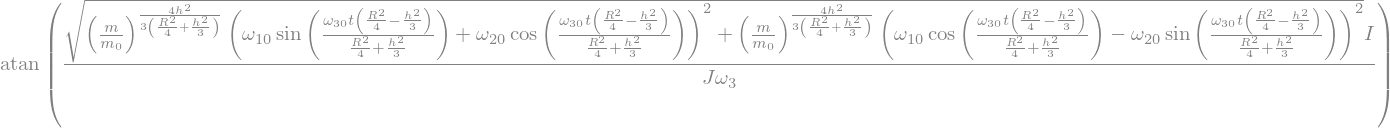

In [2]:
# Create instance for uniform burn
vms_uniform = VariableMassCylinder(burn_type='uniform')

# Run simulation
dt = 0.01  # time step
sol = vms_uniform.simulate(dt=dt, w10=0, w20=0.2, w30=0.3)


vms_uniform.theta_symbolic.subs({
            vms_uniform.omega_12_symbolic: vms_uniform.omega_12_mag_symbolic.subs({
                vms_uniform.omega_1_symbolic: vms_uniform.omega1_symbolic,
                vms_uniform.omega_2_symbolic: vms_uniform.omega2_symbolic
            })
        })

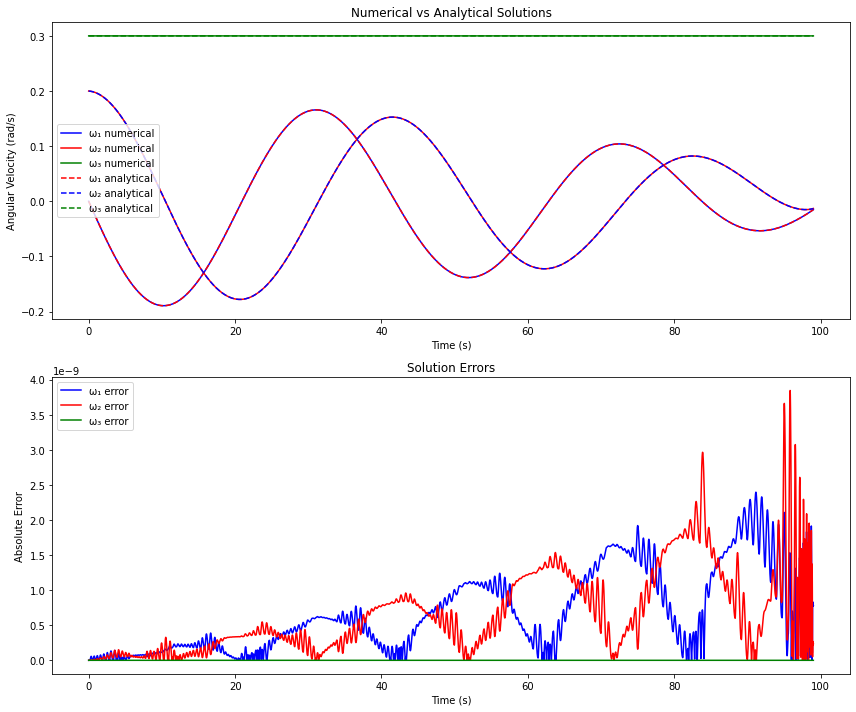

In [3]:
vms_uniform.plot_analytical_comparison()

# End burn analysis

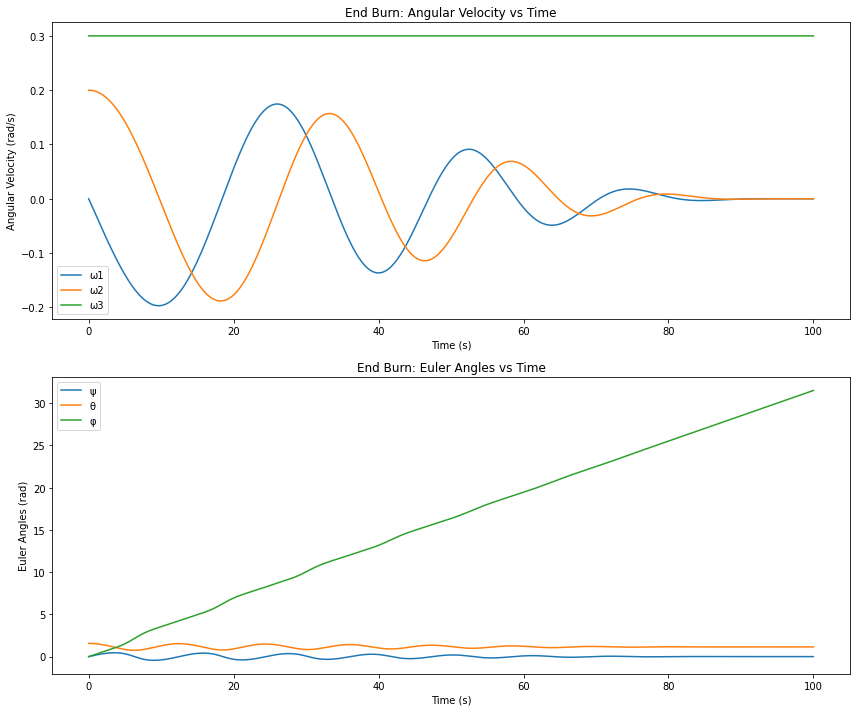

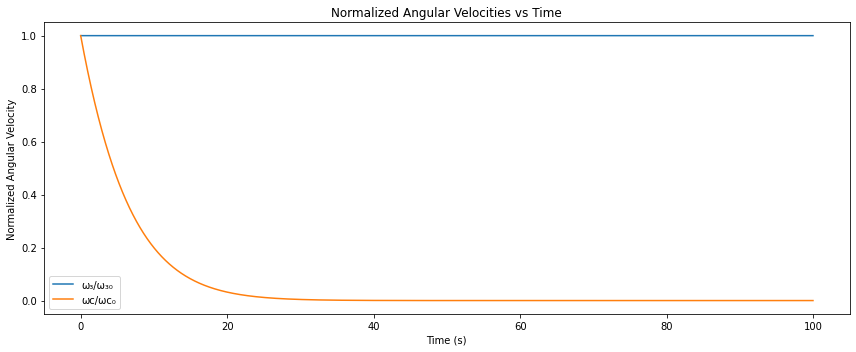

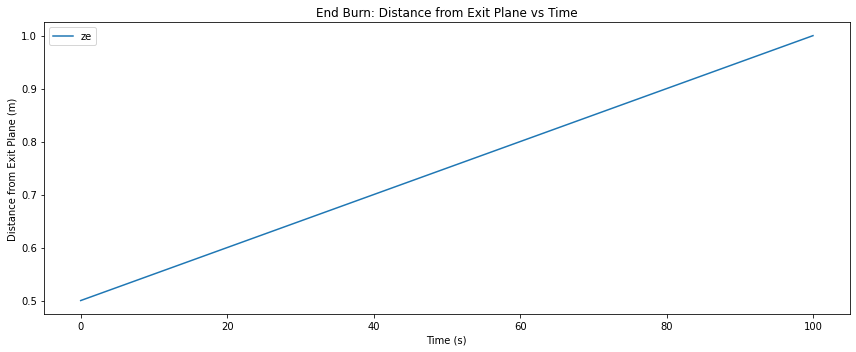

In [4]:
# Create instance for uniform burn
vms_end = VariableMassCylinder(burn_type='end')

# Run simulation
dt = 0.01  # time step
sol = vms_end.simulate(dt=dt, w10=0, w20=0.2, w30=0.3)

# Plot results
vms_end.plot_results()
vms_end.plot_normalized_omegas()
vms_end.plot_geometry()

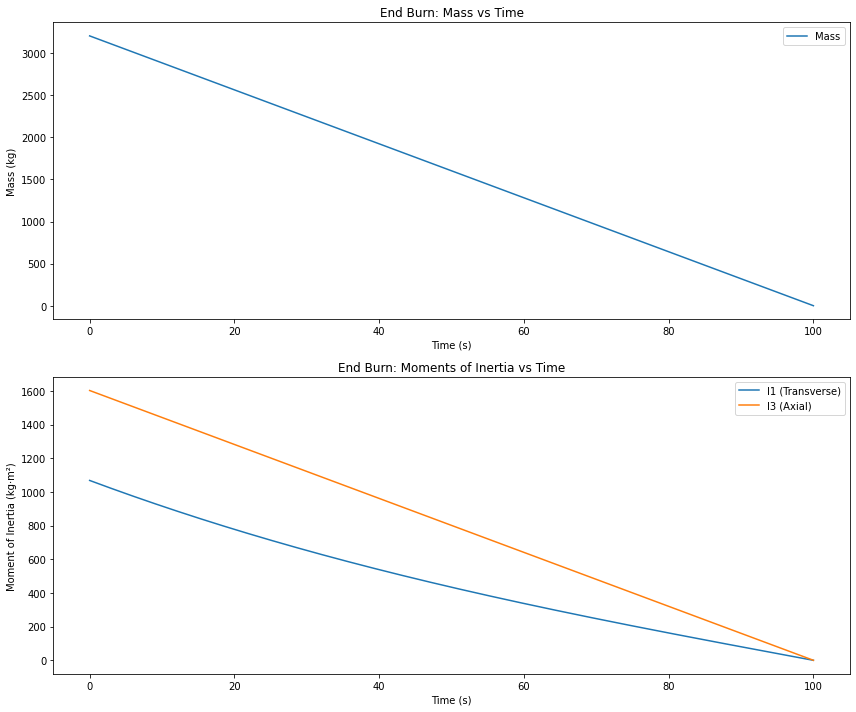

In [5]:
vms_end.plot_mass_inertia()

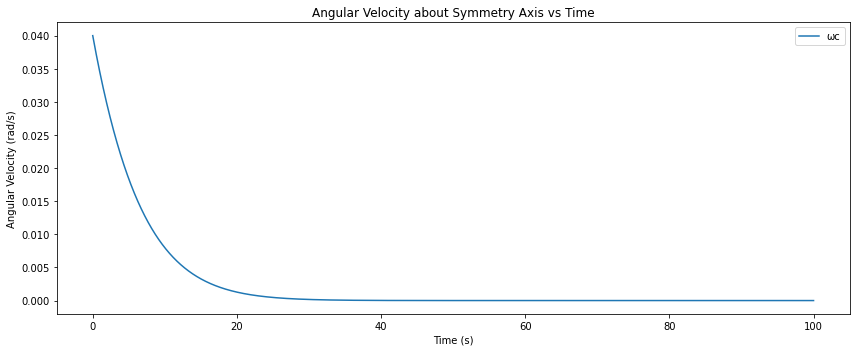

In [6]:
vms_end.plot_omega_c()

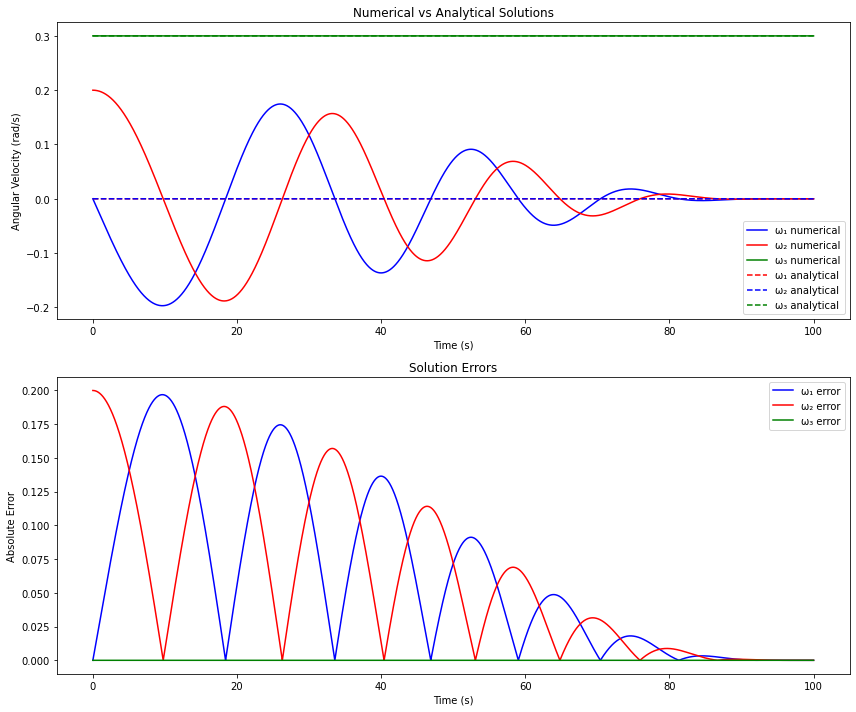

In [7]:
vms_end.plot_analytical_comparison()

# Radial burn analysis

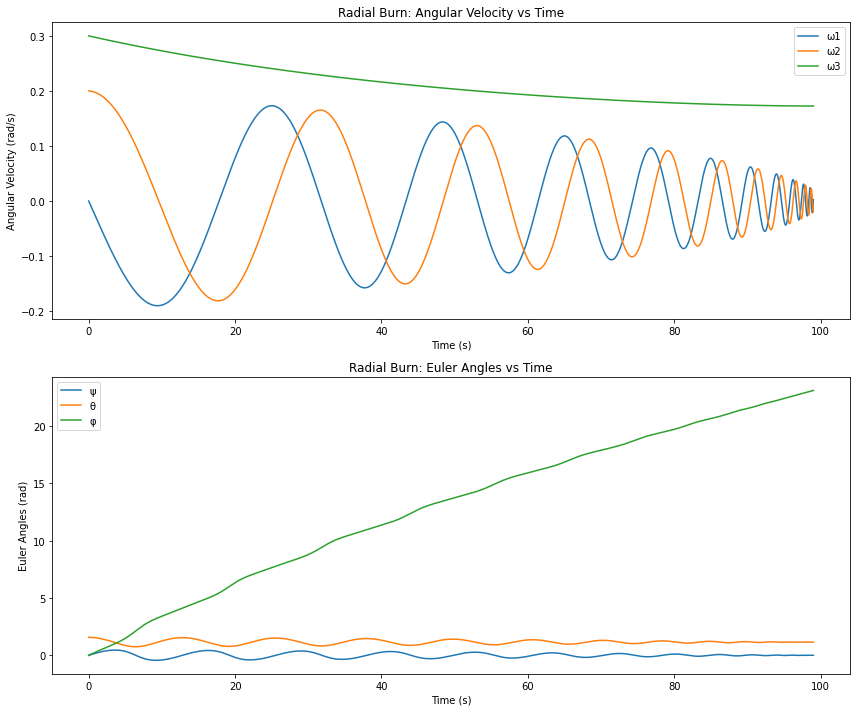

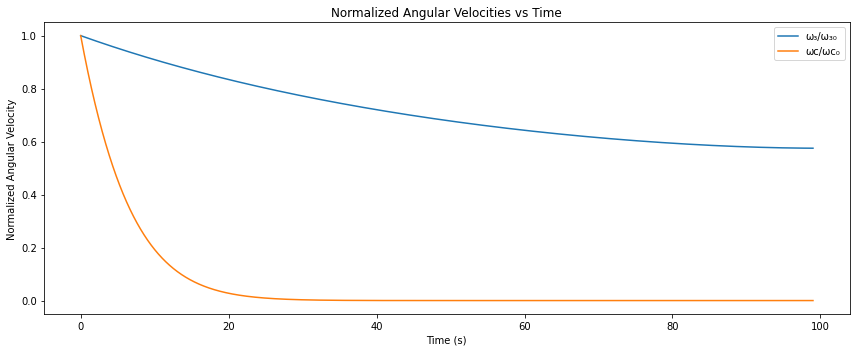

In [8]:
# Create instance for uniform burn
vms_radial = VariableMassCylinder(burn_type='radial')

# Run simulation
dt = 0.01  # time step
sol = vms_radial.simulate(dt=dt, w10=0, w20=0.2, w30=0.3)

# Plot results
vms_radial.plot_results()
vms_radial.plot_normalized_omegas()

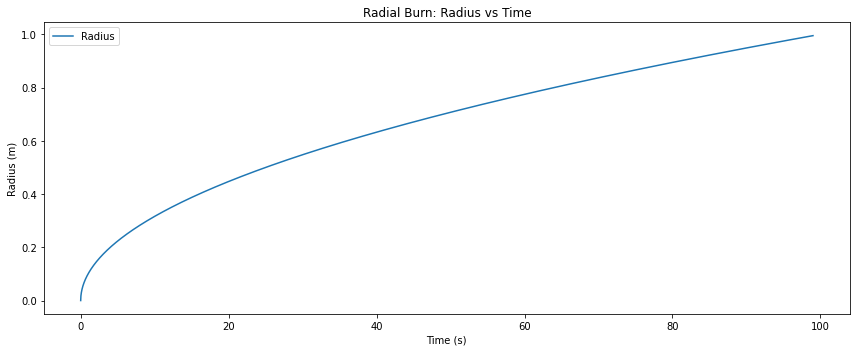

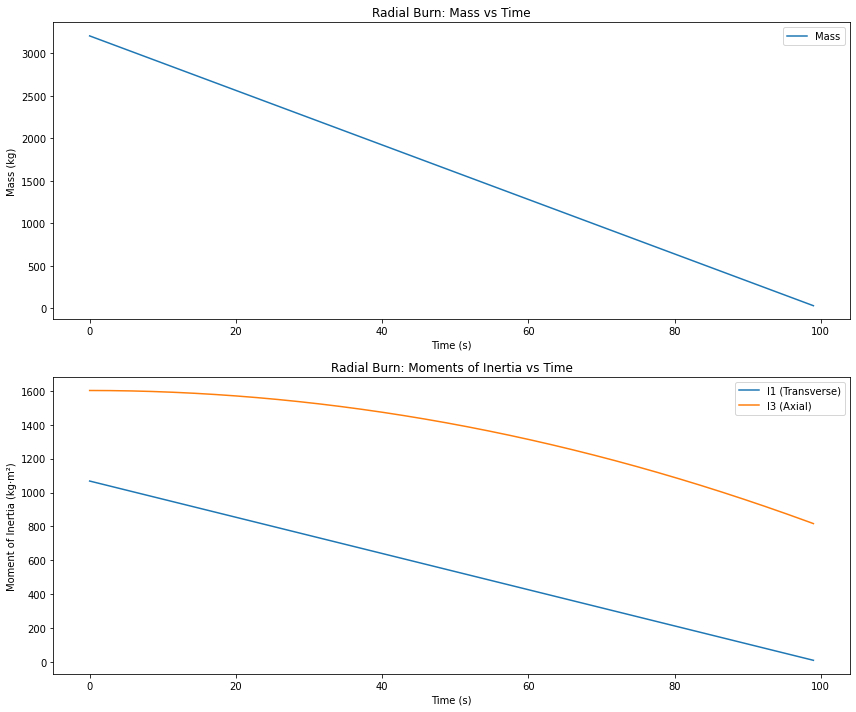

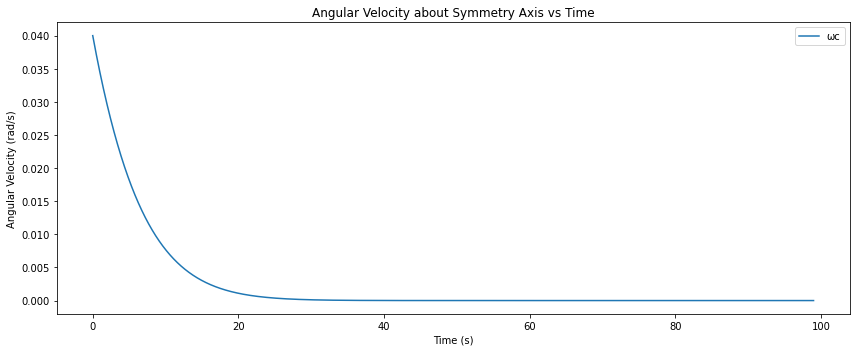

In [9]:
vms_radial.plot_geometry()
vms_radial.plot_mass_inertia()
vms_radial.plot_omega_c()

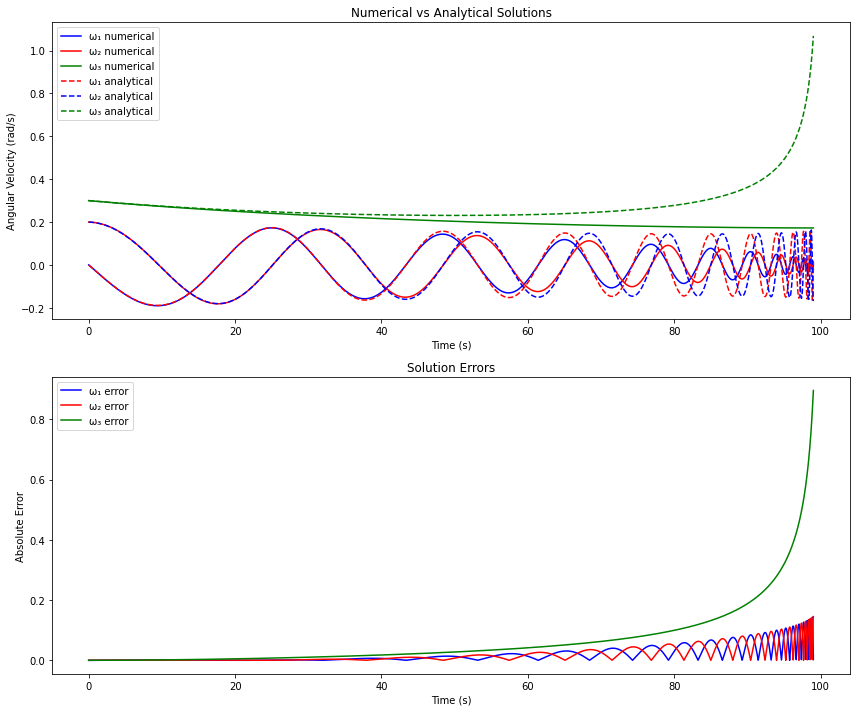

In [10]:
vms_radial.plot_analytical_comparison()

In [11]:
vms_radial.I_dot_symbolic